### Importing Required Libraries

In [1]:
# For Data Handling:
import numpy as np
import pandas as pd

# For Data Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

# Models:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Saving Model:
import pickle

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Dataset Loading

In [2]:
df=pd.read_csv("/content/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.shape

(920, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [6]:
df['target']=df['num'].apply(lambda x: 0 if x==0 else 1 )
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [7]:
df['target'].value_counts()

,count
target,
1,509
0,411


In [8]:
df.drop(['id','num','dataset'],axis=1,inplace=True)

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalch    865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    object 
 11  ca        309 non-null    float64
 12  thal      434 non-null    object 
 13  target    920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


### Handling Missing Values

In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


In [12]:
# Filling Numerical Missing Values:
num_cols=['trestbps','chol','thalch','oldpeak','ca']
for col in num_cols:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipykernel_10098/2131769807.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [13]:
# Filling Categorical Missing Values:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_10098/1255142475.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_10098/1255142475.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


" Now we need to convert the categorical data into numerical form because ML algorithms cannot directly understand text values. "

In [15]:
# Encode Categorical Features:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

for col in cat_cols:
  print(col, df[col].unique())

sex ['Male' 'Female']
cp ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
fbs [ True False]
restecg ['lv hypertrophy' 'normal' 'st-t abnormality']
exang [False  True]
slope ['downsloping' 'flat' 'upsloping']
thal ['fixed defect' 'normal' 'reversable defect']


In [16]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [17]:
df.head()

,age,trestbps,chol,thalch,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False


In [18]:
df.shape

(920, 19)

In [19]:
# Separate Features and Target:
X=df.drop('target',axis=1)
y=df['target']

In [20]:
print(X.shape)
print(y.shape)

(920, 18)
(920,)


### Train Test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
print(X_train.shape)
print(X_test.shape)

(736, 18)
(184, 18)


### Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Train Multiple Models

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

### Evaluating Diff Models:
Important metrics:

Accuracy
Overall correct predictions.

Precision

How many predicted positive cases are actually positive.

Recall ⭐: Recall measures how well a model can identify all the actual positive cases.

Most important here.

Because:

False Negative = Sick patient predicted healthy

That is dangerous.

F1-score

Balance between precision and recall.

In [25]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append([
        name,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.842391,0.841121,0.882353,0.861244
1,Decision Tree,0.793478,0.801887,0.833333,0.817308
2,Random Forest,0.869565,0.848214,0.931373,0.887850
3,SVM,0.853261,0.831858,0.921569,0.874419
4,KNN,0.853261,0.850467,0.892157,0.870813
5,Gradient Boosting,0.826087,0.830189,0.862745,0.846154


"Random Forest was selected because it achieved the best overall performance and highest recall, which helps reduce false negative predictions of heart disease cases."

-------------------------------
### Random Forest in Machine Learning (Brief Explanation)

Random Forest is a supervised machine learning algorithm that uses a collection (ensemble) of multiple Decision Trees to make predictions. It is called "Random Forest" because it creates a forest of many random decision trees.

It can be used for:

* Classification → Predicting categories (e.g., spam/not spam, disease/no disease)
* Regression → Predicting continuous values (e.g., price prediction)  
### How Random Forest Works:  
1. Creates multiple Decision Trees  
* Instead of relying on a single decision tree, Random Forest builds many trees using different random samples from the dataset.
2. Random Feature Selection
* Each tree considers a random subset of features while making decisions.
This makes trees different from each other and reduces overfitting.
3. Combines Results
* For classification:
Each tree gives a prediction (vote).
The majority vote becomes the final prediction.
* For regression:
The average of all tree predictions is taken.

### Confusion Matrix for the Random Forest model

In [26]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled,y_train)
#Prediction
y_pred=rf_model.predict(X_test_scaled)

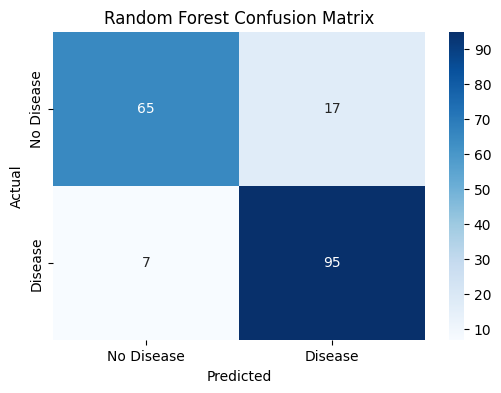

In [27]:
# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

                 Predicted
          No Disease   Disease

Actual  
No Disease         TN              FP

Disease            FN              TP

Meaning:

TN (True Negative) → Correctly predicted no heart disease  
TP (True Positive) → Correctly predicted heart disease  
FP (False Positive) → Predicted disease but actually no disease  
FN (False Negative) → Predicted no disease but actually disease

FN (False Negative) ⭐

Because this means:

The model missed a patient who actually has heart disease.

A good healthcare model tries to minimize this.

----------------------------------------
"Random Forest achieved the highest accuracy (86.95%) and recall (93.13%) among the evaluated models. Since this is a healthcare prediction problem, reducing false negatives is important, and Random Forest correctly identified most disease cases with only 7 false negatives."

### Cross Validation:
Cross-validation checks:

"Will my model perform consistently on different subsets of the data?"

In [28]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Cross Validation Scores:")
print(cv_scores)
print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.81756757 0.83673469 0.80272109 0.78231293 0.82993197]
Average Accuracy: 0.8138536495679354


In [29]:
# cross-validation recall
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(random_state=42)

cv_recall = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='recall'
)

print("Recall Scores:")
print(cv_recall)

print("Average Recall:")
print(cv_recall.mean())

Recall Scores:
[0.84146341 0.92682927 0.81481481 0.83950617 0.86419753]
Average Recall:
0.8573622402890695


"The Random Forest model achieved strong performance on the test dataset with 86.95% accuracy and 93.13% recall. To validate robustness, 5-fold cross-validation was performed, achieving an average accuracy of 81.38% and recall of 85.73%, indicating stable performance across different data splits."

---------------------
### Hyperparameter tuning :

Instead of using the default Random Forest settings, we search for the best combination of parameters that improves performance.

For Random Forest, important parameters are:

n_estimators → Number of trees  
max_depth → Maximum depth of each tree  
min_samples_split → Minimum samples required to split a node  
min_samples_leaf → Minimum samples required at a leaf node

We will use GridSearchCV.

In [30]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [31]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


In [32]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [33]:
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


* max_depth = None  
Trees are allowed to grow until they naturally stop.  
* min_samples_leaf = 1  
Each leaf can contain at least 1 sample.  
* min_samples_split = 5  
A node needs at least 5 samples before it can split.  
* n_estimators = 100  
The model will create 100 decision trees.

In [34]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

print(classification_report(y_test, y_pred_tuned))

Accuracy: 0.8532608695652174
Precision: 0.8440366972477065
Recall: 0.9019607843137255
F1 Score: 0.8720379146919431
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



### Hyperparameter Tuning

GridSearchCV was applied on the Random Forest model to optimize parameters.

The tuned model was evaluated and compared with the original Random Forest model.

Although tuning produced a competitive model, the default Random Forest achieved better accuracy, recall, and F1-score. Therefore, the original Random Forest model was selected as the final model.

In [35]:
# Final Model should be Default Random Forest without Hyperparameter tuning.
final_model=RandomForestClassifier(random_state=42)
final_model.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [36]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

y_pred_final = final_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final))

Accuracy: 0.8695652173913043
Precision: 0.8482142857142857
Recall: 0.9313725490196079
F1 Score: 0.8878504672897196
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        82
           1       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



###  Feature Importance Analysis
"Which patient health factors contributed most to the heart disease prediction?"

In [37]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,chol,0.149731
3,thalch,0.130159
0,age,0.127286
4,oldpeak,0.105350
13,exang_True,0.091405
1,trestbps,0.075363
7,cp_atypical angina,0.074803
6,sex_Male,0.043737
8,cp_non-anginal,0.033395
16,thal_normal,0.027856


### Interpretation:  
* Cholesterol has the highest influence in your model.  
* Maximum heart rate (thalch) is also a strong predictor.  
* Age is important because heart disease risk generally increases with age.  
* Oldpeak and exercise-induced angina contribute significantly because they are related to cardiac stress.  
* Blood pressure also plays an important role.  
* "Feature importance analysis showed that cholesterol, maximum heart rate, age, ST depression, and exercise-induced angina were among the most influential factors used by the Random Forest model for heart disease prediction."

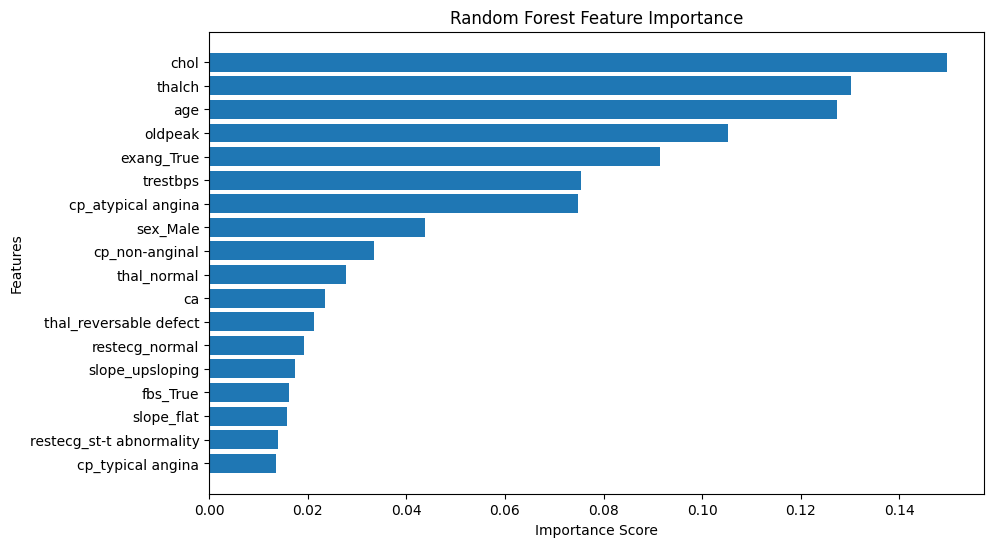

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

"Feature importance analysis was performed using the Random Forest classifier to understand the contribution of different patient attributes. The analysis showed that cholesterol level, maximum heart rate, age, ST depression, and exercise-induced angina were among the most influential features affecting heart disease prediction."  

---------------------------

In [39]:
# Save the final model files
import pickle

pickle.dump(final_model,open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully")

Model and scaler saved successfully


----------------

In [40]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/heart_disease_uci.csv")

print(df.shape)
df.head()

(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [41]:
# Convert th original target into binary classification
df['target']= (df["num"] > 0).astype(int)

# Remove coloumns that should not be used as model features
df=df.drop(columns=["id","num","dataset"])

print(df.shape)
df.head()

(920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [42]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 13)
y shape: (920,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (736, 13)
Testing data: (184, 13)


### Build the preprocessing pipeline

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Define numerical features
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]


# Define categorical features
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]


# Numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])


# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)


# Transform test data using the preprocessing learned from training data
X_test_processed = preprocessor.transform(X_test)


# Check the processed data shapes
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (736, 18)
Processed testing shape: (184, 18)


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Create the complete ML pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


# Train the pipeline using ONLY the training data
rf_pipeline.fit(X_train, y_train)


# Make predictions on unseen test data
y_pred = rf_pipeline.predict(X_test)


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("Random Forest - Leakage-Free Pipeline")
print("--------------------------------------")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest - Leakage-Free Pipeline
--------------------------------------
Accuracy :  0.8696
Precision:  0.8482
Recall   :  0.9314
F1 Score :  0.8879

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        82
           1       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

Confusion Matrix:
[[65 17]
 [ 7 95]]


ROC-AUC Score: 0.9211


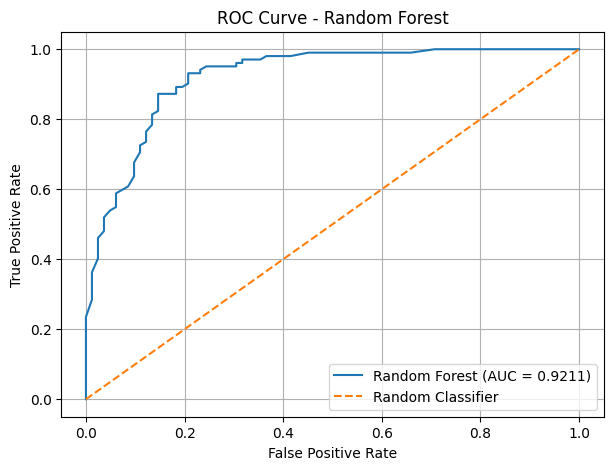

In [46]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# Get probability of the positive class
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]


# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()

plt.show()

"Achieved 86.96% test accuracy, 93.14% recall, 88.79% F1-score and 0.9211 ROC-AUC using a Random Forest classifier."

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_validate


# Define 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# Cross-validate the COMPLETE pipeline
cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# Display fold-wise results
print("Cross-Validation Results")
print("------------------------")

for metric in scoring:
    scores = cv_results[f"test_{metric}"]

    print(f"\n{metric.upper()}:")
    print(scores)

    print(f"Mean: {scores.mean():.4f}")
    print(f"Std : {scores.std():.4f}")

Cross-Validation Results
------------------------

ACCURACY:
[0.83152174 0.83695652 0.82065217 0.76086957 0.84782609]
Mean: 0.8196
Std : 0.0306

PRECISION:
[0.8125     0.83962264 0.84158416 0.79       0.8245614 ]
Mean: 0.8217
Std : 0.0190

RECALL:
[0.9009901  0.87254902 0.83333333 0.7745098  0.92156863]
Mean: 0.8606
Std : 0.0522

F1:
[0.85446009 0.85576923 0.83743842 0.78217822 0.87037037]
Mean: 0.8400
Std : 0.0308

ROC_AUC:
[0.89150662 0.8947274  0.87003826 0.84008847 0.89448828]
Mean: 0.8782
Std : 0.0211


In [48]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for Random Forest
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}


# Grid search on the COMPLETE pipeline
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X, y)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.8933


### Evaluate the tuned model on the test set

In [49]:
# Get the best tuned pipeline
tuned_model = grid_search.best_estimator_


# Predict on the untouched test set
y_pred_tuned = tuned_model.predict(X_test)


# Prediction probabilities
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]


# Calculate evaluation metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)


print("Tuned Random Forest - Test Performance")
print("---------------------------------------")
print(f"Accuracy :  {accuracy_tuned:.4f}")
print(f"Precision:  {precision_tuned:.4f}")
print(f"Recall   :  {recall_tuned:.4f}")
print(f"F1 Score :  {f1_tuned:.4f}")
print(f"ROC-AUC  :  {roc_auc_tuned:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Random Forest - Test Performance
---------------------------------------
Accuracy :  0.9402
Precision:  0.9252
Recall   :  0.9706
F1 Score :  0.9474
ROC-AUC  :  0.9889

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        82
           1       0.93      0.97      0.95       102

    accuracy                           0.94       184
   macro avg       0.94      0.94      0.94       184
weighted avg       0.94      0.94      0.94       184

Confusion Matrix:
[[74  8]
 [ 3 99]]


5-fold CV ROC-AUC before tuning = 0.8782  
Best CV ROC-AUC after tuning    = 0.8933  
Test ROC-AUC                    = 0.9889

### Cross-validate the tuned model

In [50]:
tuned_cv_results = cross_validate(
    tuned_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Random Forest - Cross-Validation")
print("--------------------------------------")

for metric in scoring:
    scores = tuned_cv_results[f"test_{metric}"]

    print(f"\n{metric.upper()}:")
    print(scores)
    print(f"Mean: {scores.mean():.4f}")
    print(f"Std : {scores.std():.4f}")

Tuned Random Forest - Cross-Validation
--------------------------------------

ACCURACY:
[0.84782609 0.8423913  0.82608696 0.79347826 0.84782609]
Mean: 0.8315
Std : 0.0206

PRECISION:
[0.8173913  0.83486239 0.83653846 0.80769231 0.8245614 ]
Mean: 0.8242
Std : 0.0108

RECALL:
[0.93069307 0.89215686 0.85294118 0.82352941 0.92156863]
Mean: 0.8842
Std : 0.0407

F1:
[0.87037037 0.86255924 0.84466019 0.81553398 0.87037037]
Mean: 0.8527
Std : 0.0208

ROC_AUC:
[0.90588095 0.91021043 0.8884505  0.85640842 0.9057867 ]
Mean: 0.8933
Std : 0.0199


So tuning produced a consistent improvement across the important metrics.

Recall increased from:

86.06% → 88.42%

Based on the improvements we use the tuned mode.


# Fixed Final model.

In [51]:
# Use the best pipeline found by GridSearchCV
final_model = grid_search.best_estimator_

print("Final Model:")
print(final_model)

Final Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHo

save the entire pipeline, rather than separately saving a scaler and model.

In [52]:
import joblib

joblib.dump(
    final_model,
    "heart_disease_final_pipeline.pkl"
)

print("Final model pipeline saved successfully.")

Final model pipeline saved successfully.


In [53]:
import joblib
import pandas as pd

# Load the final pipeline
final_model = joblib.load("heart_disease_final_pipeline.pkl")

print("Final pipeline loaded successfully!")

Final pipeline loaded successfully!


In [54]:
# Take one patient from the test set
sample_patient = X_test.iloc[[0]]

# Actual result
actual_result = y_test.iloc[0]

# Prediction
prediction = final_model.predict(sample_patient)[0]

# Probability
probability = final_model.predict_proba(sample_patient)[0][1]

print("Actual:", actual_result)
print("Predicted:", prediction)
print(f"Model probability: {probability:.2%}")

Actual: 1
Predicted: 0
Model probability: 37.06%


In [55]:
# Load the saved final pipeline
loaded_model = joblib.load("heart_disease_final_pipeline.pkl")

# Predictions from the saved model
saved_predictions = loaded_model.predict(X_test)

# Compare with the original tuned model
same_predictions = np.array_equal(
    saved_predictions,
    y_pred_tuned
)

print("Saved model loaded successfully.")
print("Predictions identical:", same_predictions)

# Calculate accuracy of the saved model
saved_accuracy = accuracy_score(y_test, saved_predictions)

print(f"Saved model accuracy: {saved_accuracy:.4f}")

Saved model loaded successfully.
Predictions identical: True
Saved model accuracy: 0.9402


In [56]:
!pip install -q shap

In [57]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [58]:
# Get the trained Random Forest from the pipeline
rf_model = final_model.named_steps["classifier"]

# Get the fitted preprocessor
fitted_preprocessor = final_model.named_steps["preprocessor"]

# Get the transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of features: 18

Feature names:
['num__age' 'num__trestbps' 'num__chol' 'num__thalch' 'num__oldpeak'
 'num__ca' 'cat__sex_Male' 'cat__cp_atypical angina' 'cat__cp_non-anginal'
 'cat__cp_typical angina' 'cat__fbs_True' 'cat__restecg_normal'
 'cat__restecg_st-t abnormality' 'cat__exang_True' 'cat__slope_flat'
 'cat__slope_upsloping' 'cat__thal_normal' 'cat__thal_reversable defect']


In [59]:
import shap

explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [60]:
shap_values = explainer.shap_values(X_test_processed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [61]:
# Select SHAP values for Class 1 (Disease)
shap_values_disease = shap_values[:, :, 1]

print("Selected SHAP values shape:", shap_values_disease.shape)

Selected SHAP values shape: (184, 18)


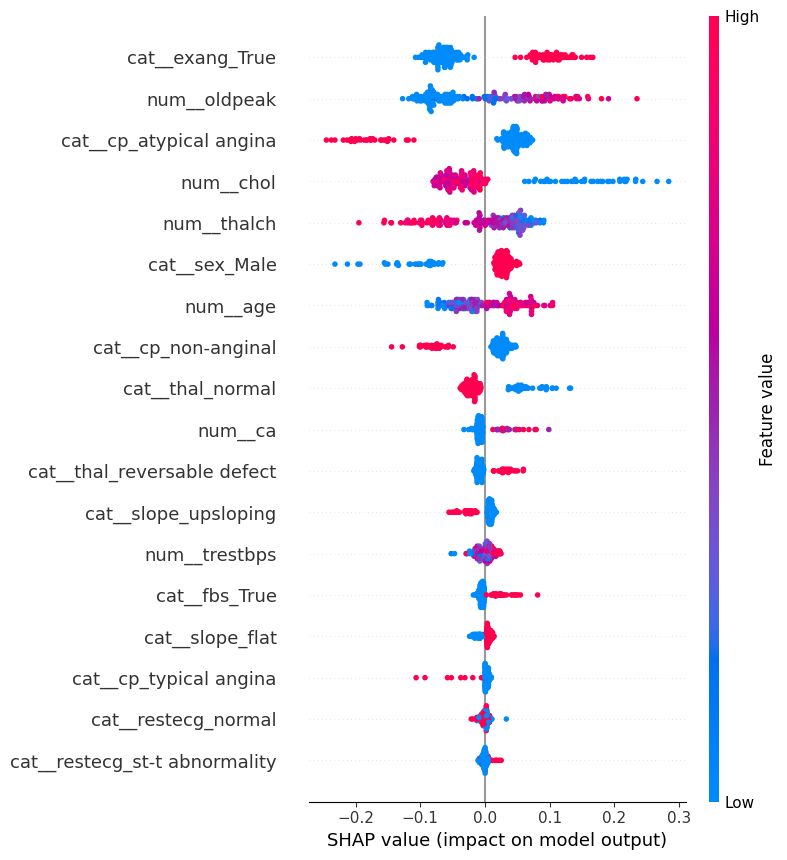

In [62]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_disease,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [63]:
# Select one patient from the test set
patient_index = 0

patient_data = X_test.iloc[[patient_index]]
patient_processed = preprocessor.transform(patient_data)

# Calculate SHAP values for this patient
patient_shap = explainer.shap_values(patient_processed)

# Select Disease (class 1)
patient_shap_disease = patient_shap[:, :, 1]

print("Patient SHAP shape:", patient_shap_disease.shape)

Patient SHAP shape: (1, 18)


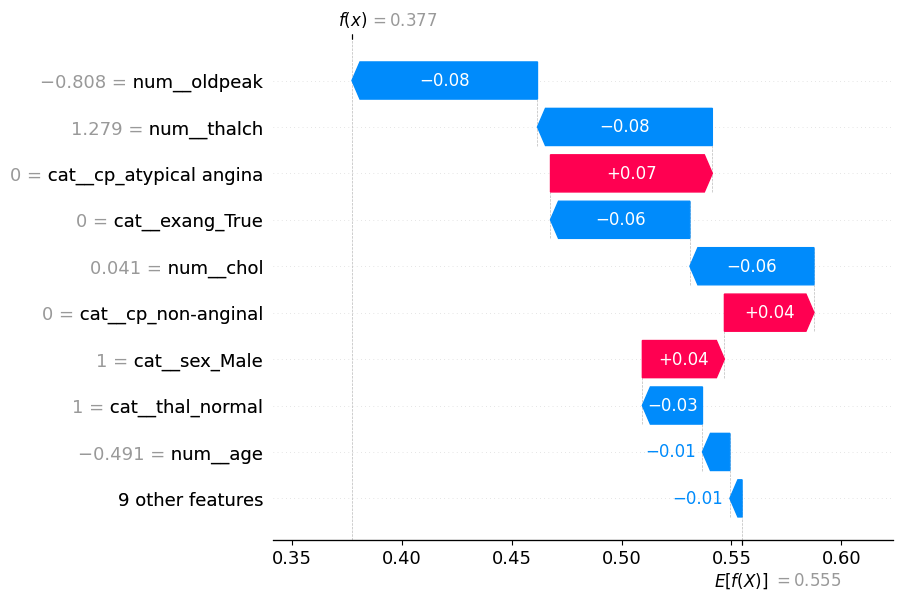

In [64]:
# Create a SHAP explanation for the selected patient
patient_explanation = shap.Explanation(
    values=patient_shap_disease[0],
    base_values=explainer.expected_value[1],
    data=patient_processed.toarray()[0] if hasattr(patient_processed, "toarray") else patient_processed[0],
    feature_names=feature_names
)

# Plot the individual explanation
shap.waterfall_plot(patient_explanation)

In [65]:
# Create a table of SHAP contributions for this patient
patient_shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": patient_shap_disease[0]
})

# Add absolute SHAP value for ranking
patient_shap_df["Absolute SHAP"] = patient_shap_df["SHAP Value"].abs()

# Sort by strongest contribution
patient_shap_df = patient_shap_df.sort_values(
    "Absolute SHAP",
    ascending=False
)

print(patient_shap_df[["Feature", "SHAP Value"]].to_string(index=False))

                      Feature  SHAP Value
                 num__oldpeak   -0.084457
                  num__thalch   -0.079610
      cat__cp_atypical angina    0.073682
              cat__exang_True   -0.063464
                    num__chol   -0.056489
          cat__cp_non-anginal    0.040780
                cat__sex_Male    0.037352
             cat__thal_normal   -0.027362
                     num__age   -0.012491
                      num__ca   -0.011946
  cat__thal_reversable defect   -0.011776
         cat__slope_upsloping    0.009941
              cat__slope_flat    0.007096
                cat__fbs_True   -0.006725
          cat__restecg_normal    0.006495
       cat__cp_typical angina    0.001370
                num__trestbps    0.000494
cat__restecg_st-t abnormality   -0.000491
